## Import libraries

In [1]:
import numpy as np
import os
import struct
from array import array
from tqdm import tqdm
from prettytable import PrettyTable

## MNIST Dataloder

* all in np.array type
* train_x = (60000, 28, 28)
* train_y = (60000,)
* test_x = (10000, 28, 28)
* test_y = (10000,)

In [2]:
class MNIST_loader:
    def __init__(self, MNIST_root):
        self.train_imgs_path = os.path.join(MNIST_root, 'train-images.idx3-ubyte')
        self.test_imgs_path = os.path.join(MNIST_root, 't10k-images.idx3-ubyte')
        self.train_labels_path = os.path.join(MNIST_root, 'train-labels.idx1-ubyte')
        self.test_labels_path = os.path.join(MNIST_root, 't10k-labels.idx1-ubyte')

    def read_data(self, mode = "train"):
        if mode == "train":
            imgs_path = self.train_imgs_path
            labels_path = self.train_labels_path
        elif mode == "test":
            imgs_path = self.test_imgs_path
            labels_path = self.test_labels_path
        
        imgs, labels = [], []
        with open(imgs_path, 'rb') as file:
            #read 16 bytes from file and read as binary in big-endian format 
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            print(f'Imgs | size = {size}, rows & cols = {rows} * {cols}')
            image_data = array("B", file.read())
        
        for i in range(size):
            #get one img every step
            img = np.array(image_data[i * rows * cols : (i + 1) * rows * cols])
            img = img.reshape(rows, cols)
            imgs.append(img)

        imgs = np.array(imgs)
        with open(labels_path, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            print(f'Labels | size = {size}')
            labels = array("B", file.read())
        
        labels = np.array(labels)

        return imgs, labels

In [3]:
data_loader = MNIST_loader("MNIST")
train_x, train_y = data_loader.read_data(mode = "train")
test_x, test_y = data_loader.read_data(mode = "test")
inputs = [train_x, train_y, test_x, test_y]

Imgs | size = 60000, rows & cols = 28 * 28
Labels | size = 60000
Imgs | size = 10000, rows & cols = 28 * 28
Labels | size = 10000


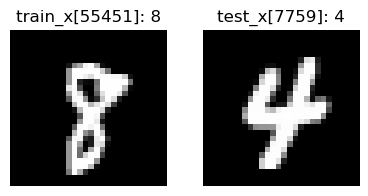

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import random

fig, axs = plt.subplots(1, 2, figsize=(4, 2))
i = random.randint(1, 60000)
axs[0].imshow(train_x[i], cmap='gray')
axs[0].set_title(f"train_x[{i}]: {train_y[i]}")
axs[0].axis('off')

j = random.randint(1, 10000)
axs[1].imshow(test_x[j], cmap='gray')
axs[1].set_title(f"test_x[{j}]: {test_y[j]}")
axs[1].axis('off')

plt.tight_layout()
plt.show()

## Naive Bayes classifier

In [5]:
class Naive_Bayes_classifier():
    def __init__(self, inputs, mode):
        assert mode in ["discrete", "continuous"], "Wrong arguments in mode"
        self.mode = mode
        if len(inputs) != 4:
            raise ValueError('Wrong inputs length {}'.format(len(inputs)))
        self.train_x, self.train_y, self.test_x, self.test_y = inputs[:]

        self.priors = {i: 0 for i in range(10)}
        for i in range(len(train_y)):
            self.priors[train_y[i]] += 1
        self.priors = {key: value / len(train_y) for key, value in self.priors.items()}
    def get_likelihood_prob(self):
        if self.mode == "discrete":
            self.likelihood_count ={i: np.ones((784, 32)) for i in range(10)}
            # since we assume all dimension is iid, we just calculate class, bins = (10, 784(28*28), 32)
            for i in tqdm(range(len(train_y))):
                flatten_xi = self.train_x[i].reshape(-1)
                for pixel_idx, pixel in enumerate(flatten_xi):
                    bin_idx = pixel // 8
                    self.likelihood_count[train_y[i]][pixel_idx, bin_idx] += 1
            
            self.likelihood_prob = {}
            for i in range(10):
                self.likelihood_prob[i] = (self.likelihood_count[i]) / self.likelihood_count[i].sum(axis=1, keepdims=True)
        elif self.mode == "continuous":
            # in continuous mode, we calculate mean and variance in gaussian for each pixel
            labels = set(self.train_y)
            self.likelihood_gaussian = {i: np.zeros((2, 784)) for i in range(10)}
            flatten_x = self.train_x.reshape(60000,784)
            for c in labels:
                x_c = flatten_x[self.train_y == c]
                self.likelihood_gaussian[c][0] = x_c.mean(axis=0)
                self.likelihood_gaussian[c][1] = x_c.var(axis=0)
                self.likelihood_gaussian[c][1][self.likelihood_gaussian[c][1] == 0] = 1
                # add smooth to var to avoid divide by zero
    def get_posterior(self):
        self.get_likelihood_prob()
        self.posterior = np.zeros((len(self.test_x), 10))
        if self.mode == "discrete":
            for i in tqdm(range(len(self.test_x))):
                flatten_xi = self.test_x[i].reshape(-1)
                loglikelihood_prob_xi = np.zeros(10)
                for pixel_idx, pixel in enumerate(flatten_xi):
                    bin_idx = pixel // 8
                    for guess_class in range(10):
                        loglikelihood_prob_xi[guess_class] += np.log(self.likelihood_prob[guess_class][pixel_idx, bin_idx])
                for j in range(10):
                    loglikelihood_prob_xi[j] += np.log(self.priors[j])
                
                self.posterior[i] = loglikelihood_prob_xi / np.sum(loglikelihood_prob_xi)
        
        elif self.mode == "continuous":
            for i in tqdm(range(len(self.test_x))):
                flatten_xi = self.test_x[i].reshape(-1)
                loglikelihood_xi = np.zeros(10)
                for guess_class in range(10):
                    mean = self.likelihood_gaussian[guess_class][0]
                    var = self.likelihood_gaussian[guess_class][1]
                    term1 = -0.5 * np.log(2 * np.pi * var)
                    term2 = -((flatten_xi - mean) ** 2) / (2 * var)
                    sum = np.sum((term1 + term2), axis=0)
                    loglikelihood_xi[guess_class] += (sum + np.log(self.priors[guess_class]))
                
                self.posterior[i] = loglikelihood_xi / np.sum(loglikelihood_xi)
    def get_predictions(self):
        error_count = 0
        for i in range(len(self.test_y)):
            print('Posterior (in log scale):')
            for j in range(10):
                print(f'{j}: {self.posterior[i][j]: .17f}')
            if self.mode == "discrete":
                print(f'Prediction: {np.argmin(self.posterior[i])}, Ans: {self.test_y[i]}')
                if np.argmin(self.posterior[i]) != self.test_y[i]:
                    error_count += 1
            elif self.mode == "continuous":
                print(f'Prediction: {np.argmin(self.posterior[i])}, Ans: {self.test_y[i]}')
                if np.argmin(self.posterior[i]) != self.test_y[i]:
                    error_count += 1
            print('\n')
        
        error = error_count / len(self.test_y)
        print(f'Error rate: {error}')

    def get_imaginations(self):
        print('Imaginations of numbers in Bayesian classifier:')
        for i in range(10):
            print('\n')
            print(f'{i}:')
            if self.mode == "discrete":
                class_i_prob = self.likelihood_prob[i]
                pixels = class_i_prob.reshape(28, 28, 32)
            elif self.mode == "continuous":
                class_i_prob = self.likelihood_gaussian[i][0]
                pixels = class_i_prob.reshape(28, 28, 1)
            table = PrettyTable()
            table.border = False
            table.header = False
            for row in pixels:
                if self.mode == "discrete":
                    table.add_row([("\033[91m1\033[0m" if np.sum(pixel[:16]) <= 0.5 else "0") for pixel in row])
                elif self.mode == "continuous":
                    table.add_row([("\033[91m1\033[0m" if pixel >= 128 else "0") for pixel in row])
            table.align = "c"
            table.padding_width = 1

            print(table)

## Experiments

In [6]:
continuous_bayes = Naive_Bayes_classifier(inputs, "continuous")
continuous_bayes.get_posterior()

100%|██████████| 10000/10000 [00:02<00:00, 4682.13it/s]


In [7]:
discrete_bayes = Naive_Bayes_classifier(inputs, "discrete")
discrete_bayes.get_posterior()

100%|██████████| 10000/10000 [01:38<00:00, 101.47it/s]


In [8]:
discrete_bayes.get_predictions()

Posterior (in log scale):
0:  0.11115533817604589
1:  0.11763260092591116
2:  0.10517186686202933
3:  0.10013750216967497
4:  0.09389200359742099
5:  0.09755836271909257
6:  0.11442027192059406
7:  0.07444161841056393
8:  0.09952134045842094
9:  0.08606909476024607
Prediction: 7, Ans: 7


Posterior (in log scale):
0:  0.10020040951796300
1:  0.10703527610354489
2:  0.08332998753571914
3:  0.09034569728975579
4:  0.10877362309335538
5:  0.09252556976147992
6:  0.08965940269603626
7:  0.11892982637095330
8:  0.09633981731530310
9:  0.11286039031588922
Prediction: 2, Ans: 2


Posterior (in log scale):
0:  0.12847683719829553
1:  0.06386485811570505
2:  0.09868145466521333
3:  0.10061294868354334
4:  0.10342484486532440
5:  0.09671184279669812
6:  0.10335360293650774
7:  0.10144903732164526
8:  0.10041020791933995
9:  0.10301436549772738
Prediction: 1, Ans: 1


Posterior (in log scale):
0:  0.07779623593480411
1:  0.14086686086543021
2:  0.09708059599688122
3:  0.09653935618761732
4:  0.10

In [9]:
discrete_bayes.get_imaginations()

Imaginations of numbers in Bayesian classifier:


0:
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  0  0  0  1  1  1  1  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  1  1  1  1  0  0  0  0  0  0  1  1  1  0  0  0  0  0  0 
 0  0  0  0 

In [10]:
continuous_bayes.get_predictions()


Posterior (in log scale):
0:  0.06882134678095116
1:  0.16993755463666929
2:  0.07070242297412514
3:  0.00470483786298212
4:  0.00419953293819654
5:  0.00375476665814341
6:  0.66690423557169587
7:  0.00285453763942060
8:  0.00519542811006702
9:  0.00292533682774897
Prediction: 7, Ans: 7


Posterior (in log scale):
0:  0.01785405358881103
1:  0.00742127498623440
2:  0.00147520326168626
3:  0.28571368808905445
4:  0.01186930992733285
5:  0.00377835154733499
6:  0.00392797952488089
7:  0.43770094877685017
8:  0.01563800504086816
9:  0.21462118525694679
Prediction: 2, Ans: 2


Posterior (in log scale):
0:  0.00006241895277430
1:  0.00004205119572250
2:  0.00005922898386946
3:  0.00005723090400414
4:  0.00005763526868891
5:  0.00005797926739297
6:  0.00005618771487698
7:  0.99948529321935298
8:  0.00005583962050077
9:  0.00006613487281677
Prediction: 1, Ans: 1


Posterior (in log scale):
0:  0.04656371101938021
1:  0.43575139402962704
2:  0.05406312066464786
3:  0.05247729208531080
4:  0.05

In [11]:
continuous_bayes.get_imaginations()

Imaginations of numbers in Bayesian classifier:


0:
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  0  0  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  0  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  0  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  0  0  0  1  1  1  1  0  0  0  0  0  0 
 0  0  0  0  0  0  0  0  0  1  1  1  1  0  0  0  0  0  0  1  1  1  0  0  0  0  0  0 
 0  0  0  0 